

<p align="center">
    <img src="https://github.com/GeostatsGuy/GeostatsPy/blob/master/TCG_color_logo.png?raw=true" width="220" height="240" />

</p>



## Stochastic Gradient–Based Optimization

#### Saris Visessumon
#### Hildebrand Department of Petroleum and Geosystems Engineering, Cockrell School of Engineering

### Subsurface Machine Learning Course, The University of Texas at Austin
#### Hildebrand Department of Petroleum and Geosystems Engineering, Cockrell School of Engineering
#### Department of Geological Sciences, Jackson School of Geosciences

_____________________

Workflow supervision and review by:

#### Instructor: Prof. Michael Pyrcz, Ph.D., P.Eng., Associate Professor, The Univeristy of Texas at Austin
[Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Geostatistics Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [Applied Geostats in Python e-book](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) | [Applied Machine Learning in Python e-book](https://geostatsguy.github.io/MachineLearningDemos_Book/) | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)

#### Course TA: Maria Gonzalez, Graduate Student, The University of Texas at Austin
##### [LinkedIn](https://www.linkedin.com/in/elnara-rustamzade/)


### Executive Summary

This project investigates whether stochastic gradient descent (SGD) converges faster than batch gradient descent (BGD), addressing the gap between the Robbins–Siegmund theoretical requirement for decaying learning rates and the constant learning-rate regimes commonly used in practical machine-learning optimization. We conduct controlled experiments on synthetic (geostatistical regression) and real (MNIST handwritten digit classification) datasets, holding all factors fixed except for the optimization method to ensure that any observed differences arise solely from convergence speed rather than confounding effects. The results show that SGD consistently reduces loss more rapidly per epoch than BGD, with mini-batch stochasticity enabling a more exploratory and efficient optimization path, whereas full-batch updates converge more slowly and exhibit reduced robustness near sharp minima. Based on these findings, we recommend using moderate batch sizes (e.g., 16–64) to achieve the best trade-off between speed, stability, and computational efficiency.


### Import Packages

In [1]:
import torch                  # for building models, performing tensor operations, computing gradients, and running the optimization workflows.
import torch.nn as nn         # provides neural-network layers to build the MLP models.
import torch.optim as optim   # provides the SGD optimizer used in all experiments.
from torchvision import datasets   # for loading the MNIST dataset.
import numpy as np            # for working with data and model arrays
import matplotlib.pyplot as plt   # for visualizing training behavior.

### Classes/Functions

The following classes/functions will be used in the workflow.

In [2]:
class MLP_MNIST(nn.Module):
    """
    MLP_MNIST is a class that defines the neural-network architecture used for MNIST classification.
    When instantiated (e.g., model = MLP_MNIST()), it produces an object (model instance) with its own trainable parameters.
    The network takes a flattened 784-dimensional image and passes it through two hidden layers (512 units each, ReLU) 
    before outputting 10 class logits.
    """
    def __init__(self, in_dim=784, h=512, out_dim=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, h),
            nn.ReLU(),
            nn.Linear(h, h),
            nn.ReLU(),
            nn.Linear(h, out_dim)
        )
    def forward(self, x):
        return self.net(x)

class MLP_GeoNet(nn.Module):
    """
    MLP_GeoNet is a class that specifies a regression model for geostatistical data.
    Creating an instance (e.g., model = MLP_GeoNet()) produces an object (model instance) with its own trainable parameters.
    The model maps 2-D spatial coordinates (x, y) through two hidden layers (64 units each, ReLU) to predict a single porosity value.
    """
    def __init__(self, in_dim=2, h=64, out_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, h),
            nn.ReLU(),
            nn.Linear(h, h),
            nn.ReLU(),
            nn.Linear(h, out_dim)
        )
    def forward(self, x):
        return self.net(x)

def train_variant_epochwise(
    base_state_dict,
    X_train_sub, y_train_sub,
    X_test, y_test,
    batch_size,
    lr,
    epochs,
    model_factory,
    criterion #different for classification and regression problems
    ):

    """
    This function trains a model for a specified batch size, learning rate, and number of epochs.
    It shuffles the data each epoch, performs mini-batch SGD updates, and records the training and test loss after each epoch 
    so that convergence behavior can be compared across different batch sizes.
    """
    
    # create model from factory
    model = model_factory()     
    model.load_state_dict(base_state_dict)
    optimizer = optim.SGD(model.parameters(), lr=lr)

    epoch_idx_hist = []
    train_loss_hist = []
    test_loss_hist = []

    n_train_local = X_train_sub.shape[0]

    for epoch in range(1, epochs + 1):

        # Shuffle data
        idx = torch.randperm(n_train_local)
        X_shuf = X_train_sub[idx]
        y_shuf = y_train_sub[idx]

        # Mini-batch training loop
        model.train()
        for i in range(0, n_train_local, batch_size):
            xb = X_shuf[i:i+batch_size]
            yb = y_shuf[i:i+batch_size]

            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

        # Compute full training & test loss
        model.eval()
        with torch.no_grad():
            train_loss = criterion(model(X_train_sub), y_train_sub).item()
            test_loss  = criterion(model(X_test),      y_test).item()

        epoch_idx_hist.append(epoch)
        train_loss_hist.append(train_loss)
        test_loss_hist.append(test_loss)

        print(f"[batch={batch_size:5d}, lr={lr:0.4f}] epoch {epoch:2d} | "
              f"train_loss={train_loss:.4f} | test_loss={test_loss:.4f}")

    return {
        "epoch_idx":  np.array(epoch_idx_hist),
        "train_loss": np.array(train_loss_hist),
        "test_loss":  np.array(test_loss_hist),
        "final_model": model,
    }

def gaussian_random_field(nx=80, ny=80, length_scale=12.0, seed=0):
    """
    Generates a synthetic 2-D Gaussian random field using FFT convolution with a Gaussian kernel.
    Used to create spatially correlated porosity data for the geostatistical regression case study.
    """
    rng = np.random.default_rng(seed)
    noise = rng.standard_normal((ny, nx))
    # Create the Gaussian kernel in real space
    x = np.arange(nx) - nx//2
    y = np.arange(ny) - ny//2
    X, Y = np.meshgrid(x, y, indexing="xy")
    sigma = length_scale
    kernel = np.exp(-(X**2 + Y**2)/(2*sigma**2))
    kernel /= kernel.sum()
    # Convolve via FFT (fast and memory-efficient)
    f_noise = np.fft.rfftn(noise)
    f_kernel = np.fft.rfftn(np.fft.ifftshift(kernel))
    field = np.fft.irfftn(f_noise * f_kernel, s=noise.shape).real
    # Normalize to mean ~0 and std ~1
    field = (field - field.mean()) / (field.std() + 1e-8)
    return field

## Dataset A - MNIST Handwritten Digit Classification
### A1) Load Data

In this workflow, we use the **MNIST handwritten digits dataset**, a public and widely used benchmark dataset for image classification.
MNIST is provided directly through `torchvision.datasets`, ensuring that the data can be downloaded reproducibly and without requiring any external or confidential files.

The full MNIST training set contains 60,000 grayscale images, and the test set contains 10,000 images.
Each image is:
* 28 × 28 pixels
* grayscale (intensity values from 0–255)
* representing a handwritten digit 0–9

For computational efficiency in this project, we work with a subset of 10,000 samples randomly selected from the training set.

We extract the following feature and target:
* Image (flattened to 784 features)
    * Input units: pixel intensity scaled to 0–1 by dividing by 255
    * Description: each MNIST image is reshaped into a 784-dimensional vector (28×28) for use in a fully connected neural network
* Label (digit 0–9)
    * Target class for classification
    * Unit: categorical (no physical units)

The dataset is loaded and prepared using the following code:

In [3]:
torch.manual_seed(0)
np.random.seed(0)

mnist_train = datasets.MNIST(root="./data", train=True,  download=True)
mnist_test  = datasets.MNIST(root="./data", train=False, download=True)

# Convert to flattened float tensors
X_train_full = mnist_train.data.float().view(-1, 28*28) / 255.0  # [60000, 784]
y_train_full = mnist_train.targets.long()                        # [60000]
X_test = mnist_test.data.float().view(-1, 28*28) / 255.0         # [10000, 784]
y_test = mnist_test.targets.long()                               # [10000]

# Subsample training set to 10,000 samples for speed
subset_n = 10000
idx_small = torch.randperm(X_train_full.shape[0])[:subset_n]
X_train = X_train_full[idx_small]
y_train = y_train_full[idx_small]

n_train = X_train.shape[0]
print("Using training subset size:", n_train)

Using training subset size: 10000


### A2) Train All Batch-Size Variants (Same Initial Weights)

Before running the batch-size experiments, two components have already been defined at the beginning of this notebook:  
(1) the `MLP_MNIST` class, which implements a fully connected MNIST classifier, and  
(2) the `train_variant_epochwise` function, which trains a model for a fixed number of epochs and records per-epoch loss.  
With these components in place, we now train all batch-size variants (full batch, 1024, 256, 64, 16, 4, and 1 for stochastic SGD) using identical initial weights, as shown below:

**Warning**: Stochastic SGD variants (batch_size = 1) take very long time to run.


In [4]:
# Number of epochs to train each configuration
epochs = 50

# Create a base model to extract a shared initial set of weights
base_model_for_init = MLP_MNIST()

# Save the initial weights so that every run starts from the same parameters
base_state = base_model_for_init.state_dict()

# Define all batch-size / learning-rate configurations to be tested
batch_configs = {
    # Full-batch gradient descent: batch size = number of training samples
    f"Full batch (B={n_train})": {"batch_size": n_train, "lr": 0.1},
    # Mini-batch variants with progressively smaller batch sizes
    "Mini-batch 1024":           {"batch_size": 1024, "lr": 0.1},
    "Mini-batch 256":            {"batch_size": 256, "lr": 0.1},
    "Mini-batch 64":             {"batch_size": 64, "lr": 0.1},
    "Mini-batch 16":             {"batch_size": 16, "lr": 0.1},
    "Mini-batch 4":              {"batch_size": 4, "lr": 0.1},
    # Pure SGD: batch size = 1
    "Stochastic (B=1) (lr=0.1)": {"batch_size": 1, "lr": 0.1},
    "Stochastic (B=1) (lr=0.01)":{"batch_size": 1, "lr": 0.01} # smaller LR to avoid overshoot
}

# Dictionary to store training histories (loss curves, accuracy, etc.) for each configuration
hists = {}

# Loss function for multi-class classification (digit 0–9).
criterion_MNIST = nn.CrossEntropyLoss()

# Loop over all batch-size configurations and train a fresh model for each
for name, cfg in batch_configs.items():
    print("\n=== Training:", name, "===")

    # Train one variant starting from the same initial weights (base_state)
    # and record its per-epoch history in the hists dictionary
    hists[name] = train_variant_epochwise(
        base_state_dict=base_state,   # shared initialization for fairness
        X_train_sub=X_train,          # training inputs
        y_train_sub=y_train,          # training labels
        X_test=X_test,                # test inputs (for monitoring)
        y_test=y_test,                # test labels (for monitoring)
        batch_size=cfg["batch_size"], # batch size for this variant
        lr=cfg["lr"],                 # learning rate for this variant
        epochs=epochs,                # fixed number of epochs
        model_factory=MLP_MNIST,      # function/class to construct a new model
        criterion=criterion_MNIST     # use cross-entropy loss for MNIST classification
    )


=== Training: Full batch (B=10000) ===
[batch=10000, lr=0.1000] epoch  1 | train_loss=2.2985 | test_loss=2.2991
[batch=10000, lr=0.1000] epoch  2 | train_loss=2.2937 | test_loss=2.2941
[batch=10000, lr=0.1000] epoch  3 | train_loss=2.2887 | test_loss=2.2891
[batch=10000, lr=0.1000] epoch  4 | train_loss=2.2838 | test_loss=2.2841
[batch=10000, lr=0.1000] epoch  5 | train_loss=2.2787 | test_loss=2.2789
[batch=10000, lr=0.1000] epoch  6 | train_loss=2.2736 | test_loss=2.2737
[batch=10000, lr=0.1000] epoch  7 | train_loss=2.2683 | test_loss=2.2683
[batch=10000, lr=0.1000] epoch  8 | train_loss=2.2629 | test_loss=2.2628
[batch=10000, lr=0.1000] epoch  9 | train_loss=2.2574 | test_loss=2.2571
[batch=10000, lr=0.1000] epoch 10 | train_loss=2.2516 | test_loss=2.2512
[batch=10000, lr=0.1000] epoch 11 | train_loss=2.2456 | test_loss=2.2451
[batch=10000, lr=0.1000] epoch 12 | train_loss=2.2393 | test_loss=2.2387
[batch=10000, lr=0.1000] epoch 13 | train_loss=2.2328 | test_loss=2.2320
[batch=1000

### A3) Plot: Training loss vs Epoch (comparing convergence speed)

With the training histories collected for all batch-size configurations, we now visualize their convergence behavior by plotting the training loss as a function of epoch. This allows us to directly compare how quickly each variant approaches lower loss values, providing an empirical measure of convergence speed across full-batch, mini-batch, and stochastic SGD settings.

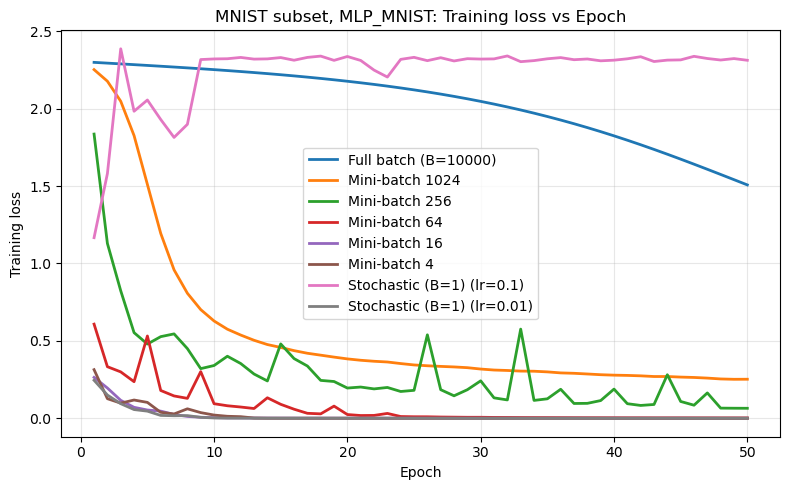

In [5]:
plt.figure(figsize=(8,5))
for name, H in hists.items():
    plt.plot(H["epoch_idx"], H["train_loss"], label=name, linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("MNIST subset, MLP_MNIST: Training loss vs Epoch")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### A4) Result
#### 1. Full-batch gradient descent (B = 10,000) converges slowly
The full-batch curve decreases gradually and remains above all mini-batch variants throughout training.
This behavior is expected: full-batch GD computes an exact gradient every update, leading to stable but relatively conservative updates that slow down early progress.

#### 2. Stochastic SGD with lr = 0.1 diverges
The stochastic SGD curve with **lr = 0.1** exhibits large spikes and fails to reduce the loss over the course of training.  
The learning rate is too large, causing the updates to overshoot consistently and resulting in **divergent behavior rather than convergence**.

To distinguish the well-performing variants, we zoom in on the y-axis.

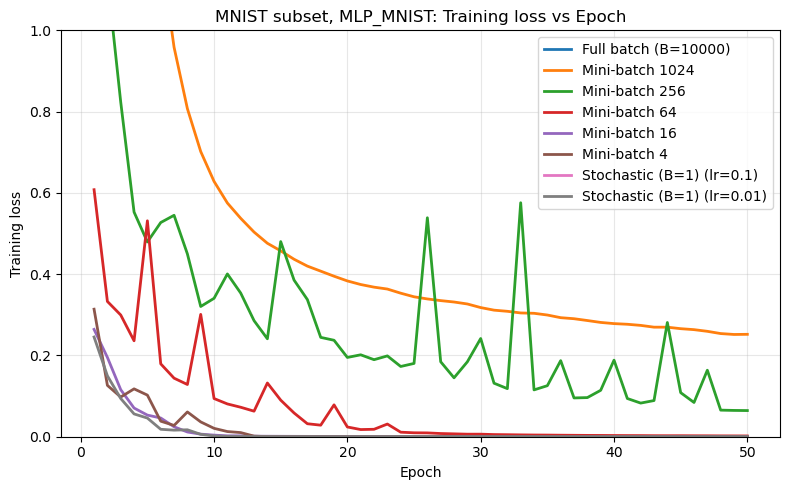

In [6]:
plt.figure(figsize=(8,5))
for name, H in hists.items():
    plt.plot(H["epoch_idx"], H["train_loss"], label=name, linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("MNIST subset, MLP_MNIST: Training loss vs Epoch")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

#### 3. Mini-batch and stochastic methods (with a well-tuned learning rate) perform the best.
In this dataset, mini-batch **B = 16** provides the strongest overall performance, converging quickly while remaining stable. Smaller batches such as B = 4 introduce too much noise and become less stable. Stochastic SGD (batch size = 1, lr = 0.01) also works well when the learning rate is carefully controlled. 

#### **Summary**
Mini-batch SGD with a small-to-moderate batch size converges faster and more reliably than full-batch GD, while pure SGD (batch_size = 1) can also perform well only when the learning rate is carefully tuned.
__________

## Dataset B - Geostatistical Regression
### B1) Generate Synthetic Geostatistical Data

We first generate a synthetic geostatistical porosity field using the previously defined `gaussian_random_field` function:

In [12]:
torch.manual_seed(0)
np.random.seed(0)

# Generate a 2D porosity field
nx, ny = 80, 80
field = gaussian_random_field(nx=nx, ny=ny, length_scale=12.0, seed=42)

C:\Users\Windows\AppData\Local\Temp\ipykernel_3832\1061595161.py:121: DeprecationWarning: `axes` should not be `None` if `s` is not `None` (Deprecated in NumPy 2.0). In a future version of NumPy, this will raise an error and `s[i]` will correspond to the size along the transformed axis specified by `axes[i]`. To retain current behaviour, pass a sequence [0, ..., k-1] to `axes` for an array of dimension k.
  field = np.fft.irfftn(f_noise * f_kernel, s=noise.shape).real


We then visualize the resulting porosity field to confirm its spatial structure:

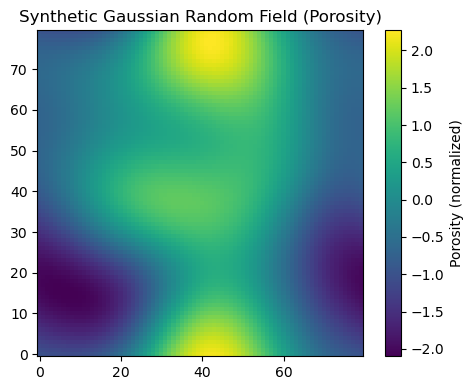

In [13]:
plt.figure(figsize=(5,4))
plt.imshow(field, cmap="viridis", origin="lower")
plt.colorbar(label="Porosity (normalized)")
plt.title("Synthetic Gaussian Random Field (Porosity)")
plt.tight_layout()
plt.show()

### B2) Build regression dataset: (x, y) -> porosity

Next, we convert the synthetic porosity field into a supervised learning dataset suitable for regression.  
Each spatial location (x, y) serves as an input feature, and the corresponding porosity value from the Gaussian random field acts as the regression target.

We first construct a normalized coordinate grid covering the 2D spatial domain.  
Each point on the grid becomes an input feature pair (x, y), and we loop through all cells to collect these coordinates into a dataset.

In [23]:
coords = []
for i in range(ny):            # loop over rows (y-direction)
    for j in range(nx):        # loop over columns (x-direction)
        coords.append([j, i])
coords = np.array(coords, dtype=np.float32)
coords_norm = (coords - coords.mean(axis=0)) / coords.std(axis=0)

X_all = np.array(coords)        # shape [N, 2]
y_all = field.reshape(-1, 1)    # converts a flat vector into a column vector (shape [N, 1]) with one target value per sample.
N_total = X_all.shape[0]

Next, we flatten a synthetic geostatistical porosity field.

In [25]:
values = []
for i in range(ny):
    for j in range(nx):
        values.append(field[i, j])
values = np.array(values, dtype=np.float32)

We then create an 80/20 train–test split by randomly permuting the dataset indices.  
This ensures that training and evaluation samples are drawn uniformly from across the spatial field.

In [33]:
# split train/test
n = len(coords_norm)
idx = np.random.permutation(n)
split = int(0.8*n)
tr_idx, te_idx = idx[:split], idx[split:]
X_train = torch.tensor(coords_norm[tr_idx])
y_train = torch.tensor(values[tr_idx]).reshape(-1, 1)    # [N, 1]
X_test  = torch.tensor(coords_norm[te_idx])
y_test  = torch.tensor(values[te_idx]).reshape(-1, 1)    # [N, 1]
n_train = X_train.shape[0]
print("Train:", n_train, "Test:", X_test.shape[0])

Train: 5120 Test: 1280


### B3) Train All Batch-Size Variants (Same Initial Weights)

Before running the batch-size experiments, two components have already been defined at the beginning of this notebook:  
(1) the `MLP_GeoNet` class, which implements a fully connected regression network for predicting porosity from spatial coordinates, and   
(2) the `train_variant_epochwise` function, which trains a model for a fixed number of epochs and records per-epoch loss.  
With these components in place, we now train all batch-size variants (full batch, 1024, 256, 64, 16, 4, and 1 for stochastic SGD) using identical initial weights, as shown below:

**Warning**: Stochastic SGD variants (batch_size = 1) take very long time to run.

In [27]:
epochs = 50

base_model_for_init = MLP_GeoNet()
base_state = base_model_for_init.state_dict()

batch_configs = {
    f"Full batch (B={n_train})": {"batch_size": n_train, "lr": 0.1},
    "Mini-batch 1024":           {"batch_size": 1024, "lr": 0.1},
    "Mini-batch 256":            {"batch_size": 256, "lr": 0.1},
    "Mini-batch 64":             {"batch_size": 64, "lr": 0.1},
    "Mini-batch 16":             {"batch_size": 16, "lr": 0.1},
    "Mini-batch 4":              {"batch_size": 4, "lr": 0.1},
    # Pure SGD: batch size = 1
    "Stochastic (B=1) (lr=0.1)": {"batch_size": 1, "lr": 0.1},
    "Stochastic (B=1) (lr=0.01)":{"batch_size": 1, "lr": 0.01} # smaller LR to avoid overshoot
}

hists_geo = {}

# Loss function for regression
criterion_GeoNet = nn.MSELoss()

for name, cfg in batch_configs.items():
    print("\n=== Training:", name, "===")
    hists_geo[name] = train_variant_epochwise(
        base_state_dict=base_state,
        X_train_sub=X_train,
        y_train_sub=y_train,
        X_test=X_test,
        y_test=y_test,
        batch_size=cfg["batch_size"],
        lr=cfg["lr"],
        epochs=epochs,
        model_factory=MLP_GeoNet,
        criterion=criterion_GeoNet
    )


=== Training: Full batch (B=5120) ===
[batch= 5120, lr=0.1000] epoch  1 | train_loss=0.9035 | test_loss=0.8889
[batch= 5120, lr=0.1000] epoch  2 | train_loss=0.8500 | test_loss=0.8337
[batch= 5120, lr=0.1000] epoch  3 | train_loss=0.8036 | test_loss=0.7861
[batch= 5120, lr=0.1000] epoch  4 | train_loss=0.7616 | test_loss=0.7434
[batch= 5120, lr=0.1000] epoch  5 | train_loss=0.7229 | test_loss=0.7044
[batch= 5120, lr=0.1000] epoch  6 | train_loss=0.6865 | test_loss=0.6682
[batch= 5120, lr=0.1000] epoch  7 | train_loss=0.6514 | test_loss=0.6334
[batch= 5120, lr=0.1000] epoch  8 | train_loss=0.6170 | test_loss=0.5995
[batch= 5120, lr=0.1000] epoch  9 | train_loss=0.5829 | test_loss=0.5662
[batch= 5120, lr=0.1000] epoch 10 | train_loss=0.5489 | test_loss=0.5332
[batch= 5120, lr=0.1000] epoch 11 | train_loss=0.5151 | test_loss=0.5005
[batch= 5120, lr=0.1000] epoch 12 | train_loss=0.4816 | test_loss=0.4684
[batch= 5120, lr=0.1000] epoch 13 | train_loss=0.4485 | test_loss=0.4367
[batch= 5120

### B4) Plot: Training loss vs Epoch (comparing convergence speed)

With the training histories collected for all batch-size configurations, we now visualize their convergence behavior by plotting the training loss as a function of epoch. This allows us to directly compare how quickly each variant approaches lower loss values, providing an empirical measure of convergence speed across full-batch, mini-batch, and stochastic SGD settings.

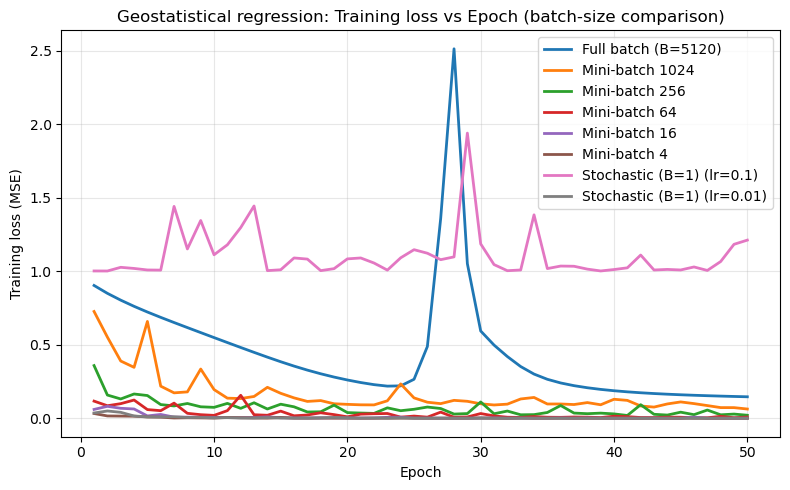

In [28]:
plt.figure(figsize=(8,5))
for name, H in hists_geo.items():
    plt.plot(H["epoch_idx"], H["train_loss"], label=name, linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Training loss (MSE)")
plt.title("Geostatistical regression: Training loss vs Epoch (batch-size comparison)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

To distinguish the well-performing variants, we zoom in on the y-axis.

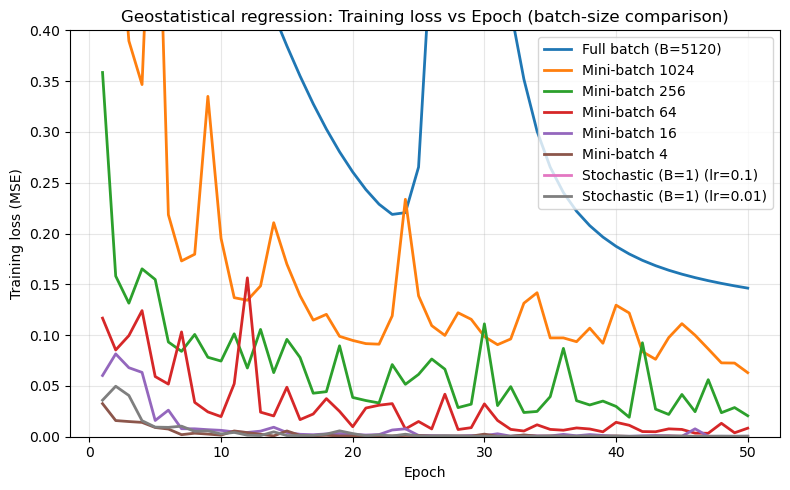

In [34]:
plt.figure(figsize=(8,5))
for name, H in hists_geo.items():
    plt.plot(H["epoch_idx"], H["train_loss"], label=name, linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Training loss (MSE)")
plt.title("Geostatistical regression: Training loss vs Epoch (batch-size comparison)")
plt.ylim(0,0.4)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### B5) Results – Geostatistical Regression

Full-batch gradient descent converges slowly and becomes unstable in later epochs, while mini-batch SGD (best at **B = 4**) and appropriately tuned stochastic methods (batch size = 1, lr = 0.01) achieve faster and smoother convergence. Stochastic SGD with a large learning rate (batch size = 1, lr = 0.1) diverges clearly. Overall, these trends are broadly consistent with the MNIST results.

The key difference is that the full-batch curve (B = 5120) exhibits a pronounced spike around epoch 28, indicating a severe overshoot in the loss landscape. This behavior suggests that the geostatistical regression objective has a sharper and more rugged loss surface than MNIST: once the optimizer enters a high-curvature region, the gradient still points downhill, but the curvature changes so rapidly that a full-sized step overshoots the local basin, causing the loss to shoot upward before recovering. Mini-batch SGD is less susceptible to this issue because gradient noise provides a **stochastic damping effect**—each update is slightly perturbed, preventing the trajectory from following the exact steepest-descent direction into the sharpest part of the valley. In this sense, mini-batch noise acts like a “shock absorber,” reducing the severity of overshoot and yielding a smoother convergence path.

To confirm that this full-batch spike is not simply due to an unlucky initialization, we perform a multi-seed comparison for full-batch GD (B = 5120) and a representative mini-batch configuration (B = 64).

### Multi-seed comparison: Full-batch GD vs Mini-batch SGD

In [36]:
seeds = [0, 1, 2, 3, 4]      # run 5 seeds (adjust as needed)
epochs = 50

batch_full = 5120            # full batch = entire dataset
batch_mb   = 64              # representative mini-batch
lr_full    = 0.1
lr_mb      = 0.1

full_histories = []
mb_histories   = []

print("Running multi-seed comparison...\n")

for seed in seeds:
    print(f"=== Seed {seed} ===")

    # Fix randomness for fairness
    torch.manual_seed(seed)
    np.random.seed(seed)

    # ----- Full-batch GD -----
    base_full = MLP_GeoNet()
    base_full_state = base_full.state_dict()

    hist_full = train_variant_epochwise(
        base_state_dict=base_full_state,
        X_train_sub=X_train,
        y_train_sub=y_train,
        X_test=X_test,
        y_test=y_test,
        batch_size=batch_full,
        lr=lr_full,
        epochs=epochs,
        model_factory=MLP_GeoNet,
        criterion=criterion_GeoNet
    )
    full_histories.append(hist_full["test_loss"])

    # ----- Mini-batch SGD (B = 64) -----
    base_mb = MLP_GeoNet()
    base_mb_state = base_mb.state_dict()

    hist_mb = train_variant_epochwise(
        base_state_dict=base_mb_state,
        X_train_sub=X_train,
        y_train_sub=y_train,
        X_test=X_test,
        y_test=y_test,
        batch_size=batch_mb,
        lr=lr_mb,
        epochs=epochs,
        model_factory=MLP_GeoNet,
        criterion=criterion_GeoNet
    )
    mb_histories.append(hist_mb["test_loss"])

Running multi-seed comparison...

=== Seed 0 ===
[batch= 5120, lr=0.1000] epoch  1 | train_loss=0.9267 | test_loss=0.8712
[batch= 5120, lr=0.1000] epoch  2 | train_loss=0.8519 | test_loss=0.7989
[batch= 5120, lr=0.1000] epoch  3 | train_loss=0.7965 | test_loss=0.7456
[batch= 5120, lr=0.1000] epoch  4 | train_loss=0.7526 | test_loss=0.7037
[batch= 5120, lr=0.1000] epoch  5 | train_loss=0.7159 | test_loss=0.6688
[batch= 5120, lr=0.1000] epoch  6 | train_loss=0.6836 | test_loss=0.6383
[batch= 5120, lr=0.1000] epoch  7 | train_loss=0.6537 | test_loss=0.6102
[batch= 5120, lr=0.1000] epoch  8 | train_loss=0.6250 | test_loss=0.5834
[batch= 5120, lr=0.1000] epoch  9 | train_loss=0.5969 | test_loss=0.5572
[batch= 5120, lr=0.1000] epoch 10 | train_loss=0.5689 | test_loss=0.5312
[batch= 5120, lr=0.1000] epoch 11 | train_loss=0.5410 | test_loss=0.5053
[batch= 5120, lr=0.1000] epoch 12 | train_loss=0.5131 | test_loss=0.4795
[batch= 5120, lr=0.1000] epoch 13 | train_loss=0.4849 | test_loss=0.4535
[b

We then plot multi-seed results

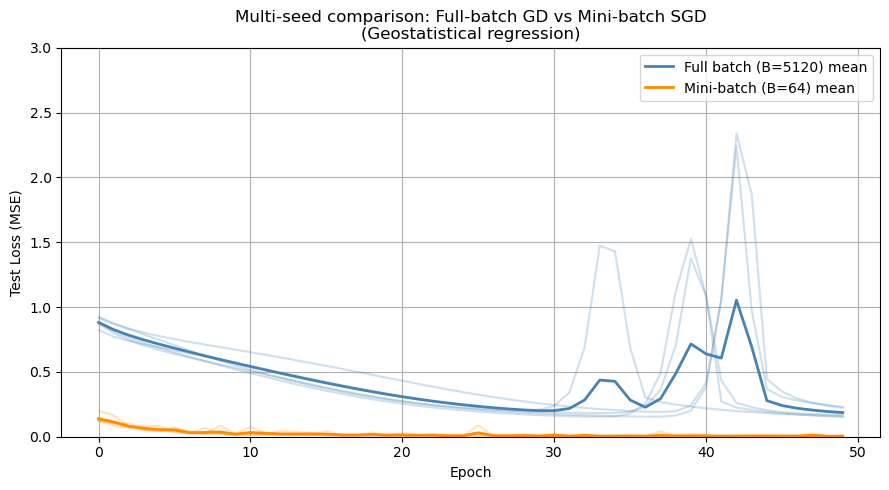

In [37]:
full_histories = np.array(full_histories)   # shape [n_seeds, epochs]
mb_histories   = np.array(mb_histories)

mean_full = full_histories.mean(axis=0)
mean_mb   = mb_histories.mean(axis=0)

plt.figure(figsize=(9,5))

# Plot all full-batch curves
for h in full_histories:
    plt.plot(h, color="steelblue", alpha=0.25)

# Plot all mini-batch curves
for h in mb_histories:
    plt.plot(h, color="darkorange", alpha=0.25)

# Plot means
plt.plot(mean_full, color="steelblue", linewidth=2, label=f"Full batch (B={batch_full}) mean")
plt.plot(mean_mb,   color="darkorange", linewidth=2, label=f"Mini-batch (B={batch_mb}) mean")

plt.xlabel("Epoch")
plt.ylabel("Test Loss (MSE)")
plt.title("Multi-seed comparison: Full-batch GD vs Mini-batch SGD\n(Geostatistical regression)")
plt.ylim(0, 3)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Each thin line corresponds to a different random initialization, while the bold line and shaded band show the mean and variability across seeds. The full-batch trajectories consistently display late-epoch spikes and much higher variance, confirming that instability is a systematic phenomenon on this loss surface rather than a one-off seed. In contrast, the mini-batch (B = 64) curves cluster tightly with a smooth, monotone decrease in test loss, demonstrating robust and seed-insensitive convergence.

Overall, the geostatistical regression results reinforce the conclusion that **mini-batch SGD with a small-to-moderate batch size converges faster and more reliably than full-batch GD**, while pure SGD can also perform well only when the learning rate is carefully tuned. 

Interestingly, the “best” batch size differs between the two datasets (B = 16 for MNIST vs. B = 4 for the geostatistical regression).
This suggests that the geostatistical loss surface is sharper and more irregular, requiring more gradient noise to stabilize optimization.
Smaller batch sizes (e.g., B = 4) introduce enough stochasticity to dampen overshooting in high-curvature regions, whereas MNIST’s smoother, classification-oriented loss benefits from a slightly larger batch (B = 16) for faster and more stable convergence.
________

#### About the Supervising Professor

Michael Pyrcz is a professor in the [Cockrell School of Engineering](https://cockrell.utexas.edu/faculty-directory/alphabetical/p), and the [Jackson School of Geosciences](https://www.jsg.utexas.edu/researcher/michael_pyrcz/), at [The University of Texas at Austin](https://www.utexas.edu/), where he researches and teaches subsurface, spatial data analytics, geostatistics, and machine learning. Michael is also,

* the principal investigator of the [Energy Analytics](https://fri.cns.utexas.edu/energy-analytics) freshmen research initiative and a core faculty in the Machine Learn Laboratory in the College of Natural Sciences, The University of Texas at Austin

* an associate editor for [Computers and Geosciences](https://www.sciencedirect.com/journal/computers-and-geosciences/about/editorial-board), and a board member for [Mathematical Geosciences](https://link.springer.com/journal/11004/editorial-board), the International Association for Mathematical Geosciences. 

Michael has written over 70 [peer-reviewed publications](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en), a [Python package](https://pypi.org/project/geostatspy/) for spatial data analytics, co-authored a textbook on spatial data analytics, [Geostatistical Reservoir Modeling](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) and author of two recently released e-books, [Applied Geostatistics in Python: a Hands-on Guide with GeostatsPy](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) and [Applied Machine Learning in Python: a Hands-on Guide with Code](https://geostatsguy.github.io/MachineLearningDemos_Book/intro.html).

All of Michael’s university lectures are available on his [YouTube Channel](https://www.youtube.com/@GeostatsGuyLectures) with links to 100s of Python interactive dashboards and well-documented workflows in over 40 repositories on his [GitHub account](https://github.com/GeostatsGuy), to support any interested students and working professionals with evergreen content. To find out more about Michael’s work and shared educational resources visit his [Website](www.michaelpyrcz.com).

#### Want to Work Together?

I hope this content is helpful to those that want to learn more about subsurface modeling, data analytics and machine learning. Students and working professionals are welcome to participate.

* Want to invite me to visit your company for training, mentoring, project review, workflow design and / or consulting? I'd be happy to drop by and work with you! 

* Interested in partnering, supporting my graduate student research or my Subsurface Data Analytics and Machine Learning consortium (co-PI is Professor John Foster)? My research combines data analytics, stochastic modeling and machine learning theory with practice to develop novel methods and workflows to add value. We are solving challenging subsurface problems!

* I can be reached at mpyrcz@austin.utexas.edu.

I'm always happy to discuss,

*Michael*

Michael Pyrcz, Ph.D., P.Eng. Professor, Cockrell School of Engineering and The Jackson School of Geosciences, The University of Texas at Austin

More Resources Available at: [Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Geostatistics Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [Applied Geostats in Python e-book](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) | [Applied Machine Learning in Python e-book](https://geostatsguy.github.io/MachineLearningDemos_Book/) | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)